# Air Quality Index (AQI) Analysis : Delhi
**Intermediate Data Science Task**


##  Objective
Conduct an in-depth analysis of the Air Quality Index (AQI) in Delhi by:
- Defining key research questions around pollutants, temporal patterns, and diurnal trends
- Using statistical analyses to understand pollutant behavior
- Building rich visualizations to communicate insights
- Offering public health recommendations based on findings


## Research Questions
1. What are the concentration levels and distributions of key pollutants (PM2.5, PM10, CO, NO₂, SO₂, O₃, NO, NH₃)?
2. How does AQI vary across different times of the day (diurnal patterns)?
3. Which pollutants are most strongly correlated with each other?
4. What are the peak pollution hours and how dangerous are they?
5. What is the computed AQI category distribution and what does it mean for public health?
6. Are there early-morning vs evening pollution spikes?



## 1.  Install & Import Libraries

In [ ]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scipy -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print(' All libraries loaded successfully!')

 All libraries loaded successfully!


## 2.  Load & Inspect Dataset

In [ ]:

df = pd.read_csv('/content/delhiaqi.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

Dataset Shape: (561, 9)
Columns: ['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']


,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19
5,2023-01-01 05:00:00,3578.19,64.37,55.52,14.13,44.35,276.54,336.79,16.21
6,2023-01-01 06:00:00,3578.19,46.94,76.09,33.26,50.54,295.40,357.07,19.25
7,2023-01-01 07:00:00,1468.66,9.83,47.30,105.86,68.66,158.83,182.61,7.09
8,2023-01-01 08:00:00,1161.58,5.81,35.99,125.89,61.99,134.39,153.47,5.51
9,2023-01-01 09:00:00,1161.58,4.58,36.33,134.47,65.80,133.22,152.09,6.02


In [ ]:
# Basic info
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    561 non-null    object 
 1   co      561 non-null    float64
 2   no      561 non-null    float64
 3   no2     561 non-null    float64
 4   o3      561 non-null    float64
 5   so2     561 non-null    float64
 6   pm2_5   561 non-null    float64
 7   pm10    561 non-null    float64
 8   nh3     561 non-null    float64
dtypes: float64(8), object(1)
memory usage: 39.6+ KB

=== Missing Values ===
date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64

=== Statistical Summary ===


,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,561.00,561.00,561.00,561.00,561.00,561.00,561.00,561.00
mean,3814.94,51.18,75.29,30.14,64.66,358.26,420.99,26.43
std,3227.74,83.90,42.47,39.98,61.07,227.36,271.29,36.56
min,654.22,0.00,13.37,0.00,5.25,60.10,69.08,0.63
25%,1708.98,3.38,44.55,0.07,28.13,204.45,240.90,8.23
50%,2590.18,13.30,63.75,11.80,47.21,301.17,340.90,14.82
75%,4432.68,59.01,97.33,47.21,77.25,416.65,482.57,26.35
max,16876.22,425.58,263.21,164.51,511.17,1310.20,1499.27,267.51


## 3.  Data Preprocessing

In [ ]:
# Parse datetime
df['date'] = pd.to_datetime(df['date'])

# Extract time features
df['hour']    = df['date'].dt.hour
df['day']     = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()
df['date_only'] = df['date'].dt.date

# Time-of-day bins
def time_of_day(hour):
    if 5 <= hour < 12:  return 'Morning (5-12)'
    elif 12 <= hour < 17: return 'Afternoon (12-17)'
    elif 17 <= hour < 21: return 'Evening (17-21)'
    else: return 'Night (21-5)'

df['time_of_day'] = df['hour'].apply(time_of_day)

# Pollutant columns
pollutants = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']

# --- Compute AQI (simplified India NAAQS-based sub-index) ---
def compute_aqi_pm25(c):
    """Sub-index for PM2.5 (µg/m³) — India CPCB breakpoints"""
    breakpoints = [
        (0,    30,   0,   50),
        (30,   60,   51,  100),
        (60,   90,   101, 200),
        (90,   120,  201, 300),
        (120,  250,  301, 400),
        (250,  500,  401, 500),
    ]
    for (cl, ch, il, ih) in breakpoints:
        if cl <= c <= ch:
            return ((ih - il) / (ch - cl)) * (c - cl) + il
    return 500

def compute_aqi_pm10(c):
    """Sub-index for PM10 (µg/m³)"""
    breakpoints = [
        (0,    50,   0,   50),
        (50,   100,  51,  100),
        (100,  250,  101, 200),
        (250,  350,  201, 300),
        (350,  430,  301, 400),
        (430,  600,  401, 500),
    ]
    for (cl, ch, il, ih) in breakpoints:
        if cl <= c <= ch:
            return ((ih - il) / (ch - cl)) * (c - cl) + il
    return 500

df['aqi_pm25'] = df['pm2_5'].apply(compute_aqi_pm25)
df['aqi_pm10'] = df['pm10'].apply(compute_aqi_pm10)
df['AQI']      = df[['aqi_pm25', 'aqi_pm10']].max(axis=1).round(0)

def aqi_category(aqi):
    if aqi <= 50:   return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else:            return 'Severe'

df['AQI_Category'] = df['AQI'].apply(aqi_category)

print(f'Date Range : {df["date"].min()} → {df["date"].max()}')
print(f'Total rows : {len(df)}')
print(f'AQI range  : {df["AQI"].min():.0f} – {df["AQI"].max():.0f}')
print(f'Mean AQI   : {df["AQI"].mean():.1f}')
print('\nAQI Category Distribution:')
print(df['AQI_Category'].value_counts())

Date Range : 2023-01-01 00:00:00 → 2023-01-24 08:00:00
Total rows : 561
AQI range  : 101 – 500
Mean AQI   : 412.8

AQI Category Distribution:
AQI_Category
Severe       357
Very Poor    183
Poor          15
Moderate       6
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

### 4.1 Pollutant Distribution — Box Plots

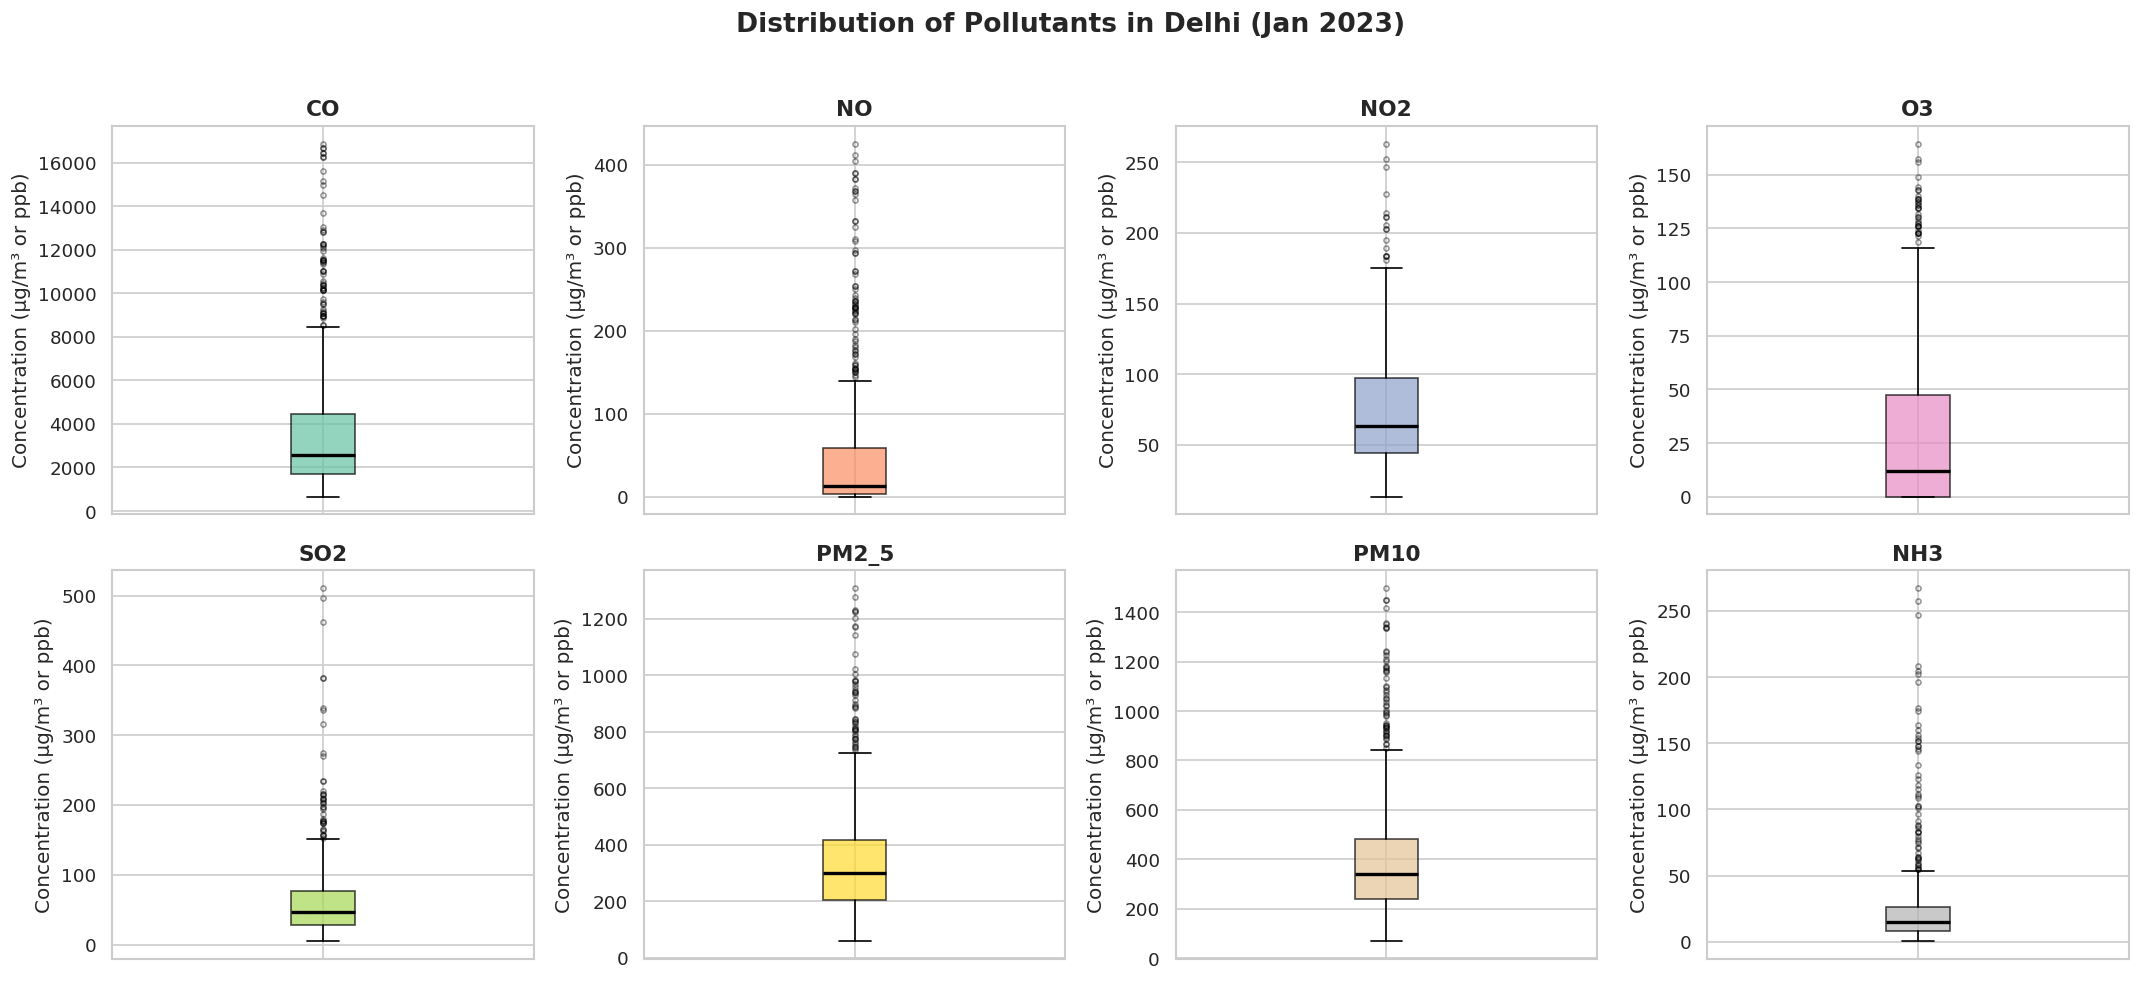

 Insight: PM2.5, PM10, and CO show high right-skewed distributions with extreme outliers — indicating pollution spikes.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = sns.color_palette('Set2', len(pollutants))

for i, (pol, color) in enumerate(zip(pollutants, colors)):
    axes[i].boxplot(df[pol].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    axes[i].set_title(pol.upper(), fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Concentration (µg/m³ or ppb)')
    axes[i].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

plt.suptitle('Distribution of Pollutants in Delhi (Jan 2023)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_pollutant_boxplots.png', bbox_inches='tight')
plt.show()
print(' Insight: PM2.5, PM10, and CO show high right-skewed distributions with extreme outliers — indicating pollution spikes.')

### 4.2 Pollutant Distribution — Histograms with KDE

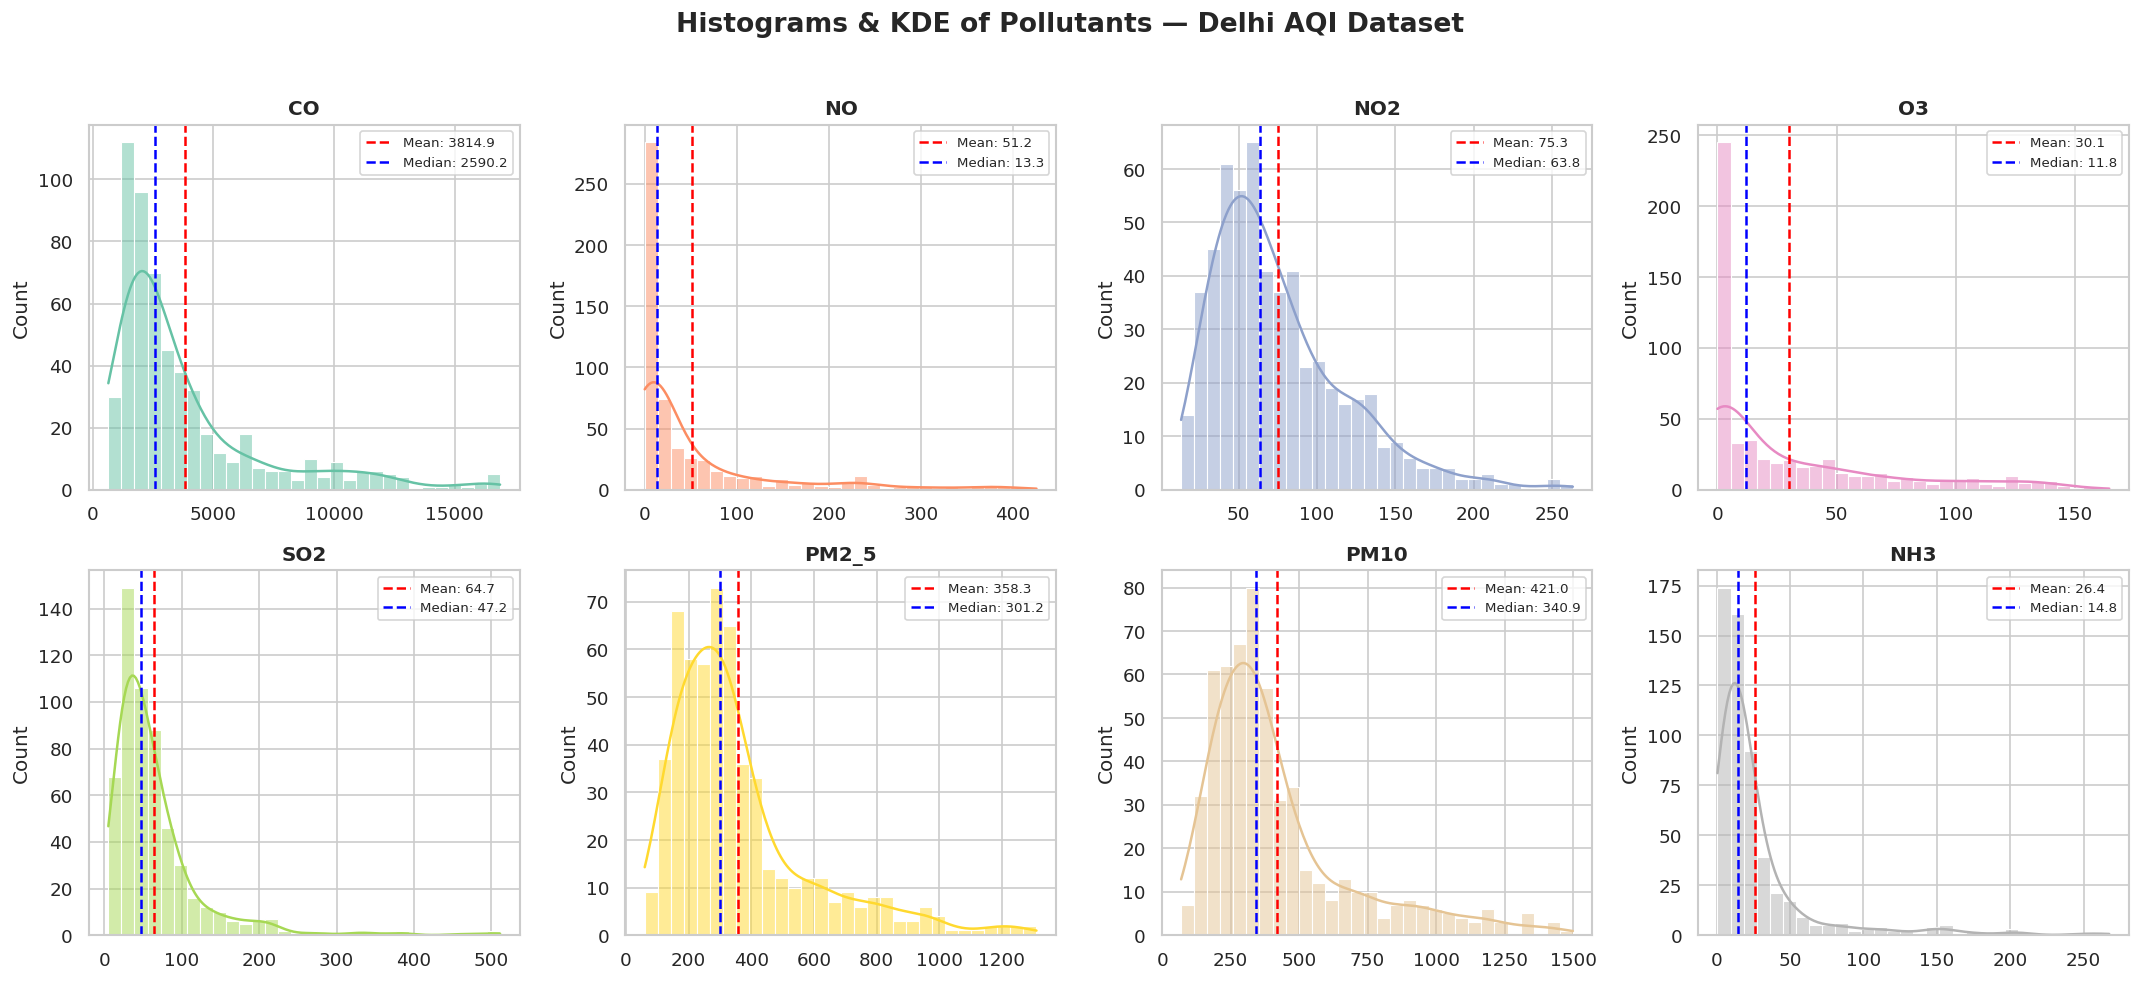

 Insight: Most pollutants are right-skewed, confirming intermittent high-pollution episodes.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (pol, color) in enumerate(zip(pollutants, colors)):
    sns.histplot(df[pol], kde=True, ax=axes[i], color=color, bins=30, edgecolor='white')
    axes[i].axvline(df[pol].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[pol].mean():.1f}')
    axes[i].axvline(df[pol].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {df[pol].median():.1f}')
    axes[i].set_title(pol.upper(), fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Histograms & KDE of Pollutants — Delhi AQI Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_pollutant_histograms.png', bbox_inches='tight')
plt.show()
print(' Insight: Most pollutants are right-skewed, confirming intermittent high-pollution episodes.')

## 5.  Diurnal (Hourly) Patterns

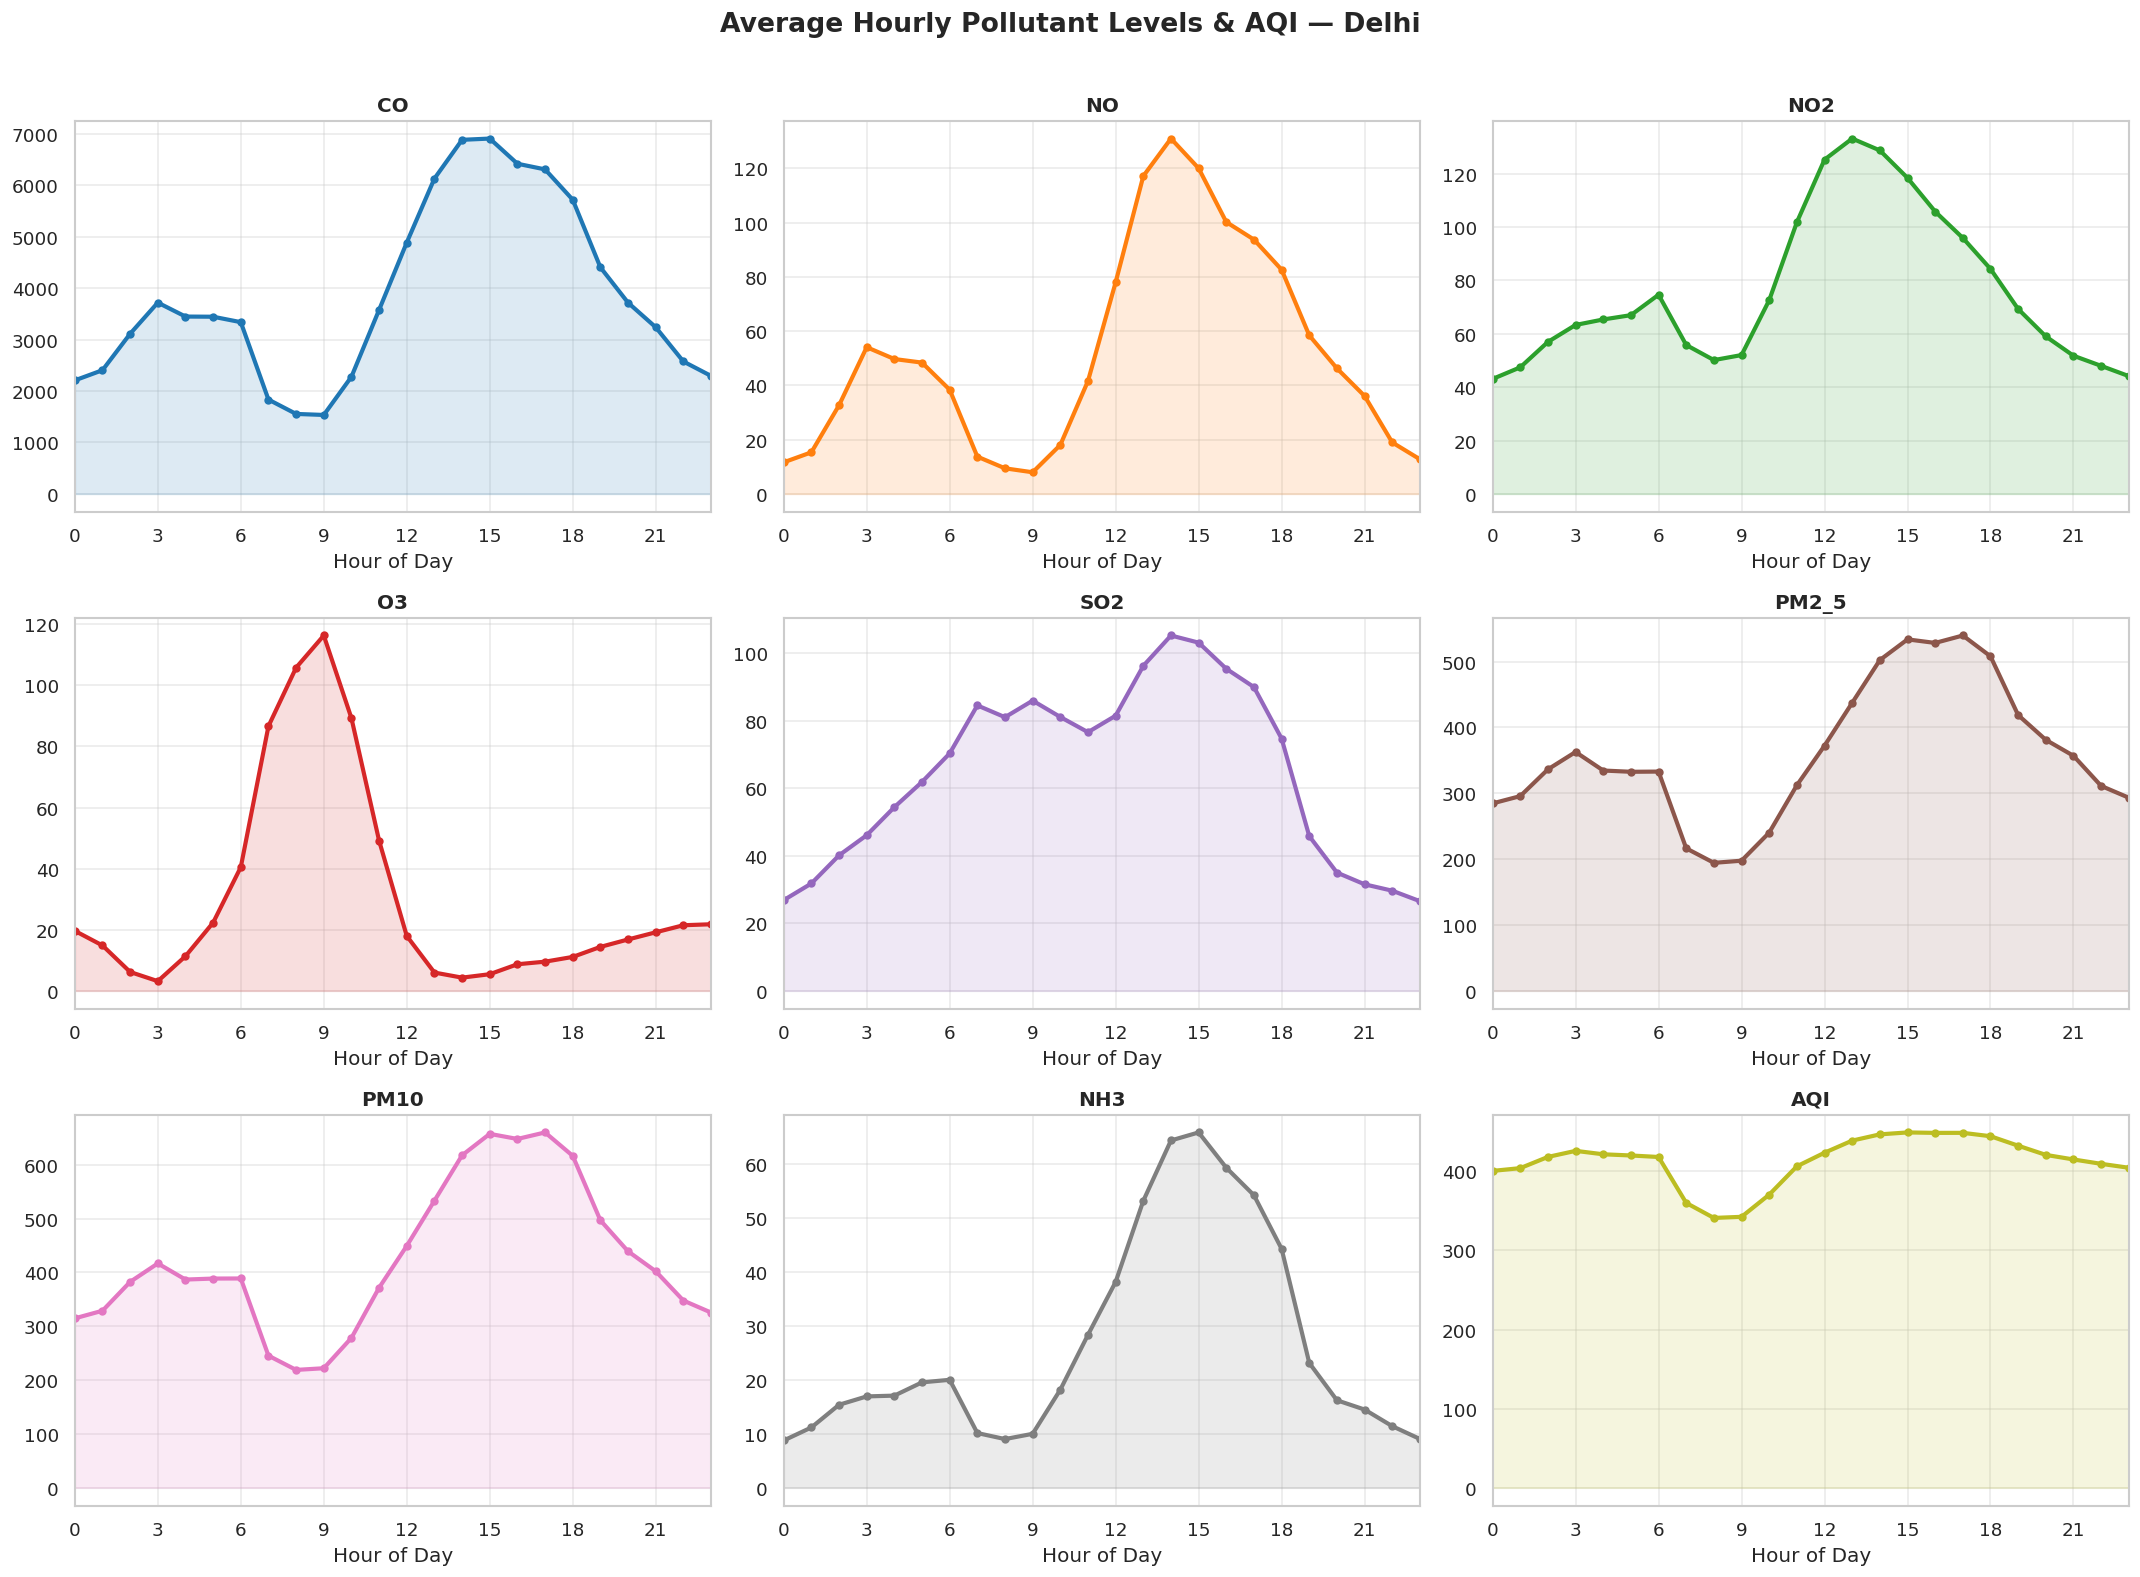

 Insight: Most pollutants peak in early morning hours (2–5 AM) due to temperature inversions trapping emissions close to the ground.


In [ ]:
hourly_avg = df.groupby('hour')[pollutants + ['AQI']].mean()

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()

all_cols = pollutants + ['AQI']
plot_colors = sns.color_palette('tab10', len(all_cols))

for i, (col, color) in enumerate(zip(all_cols, plot_colors)):
    axes[i].plot(hourly_avg.index, hourly_avg[col], color=color, linewidth=2.5, marker='o', markersize=4)
    axes[i].fill_between(hourly_avg.index, hourly_avg[col], alpha=0.15, color=color)
    axes[i].set_title(col.upper(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Hour of Day')
    axes[i].set_xticks(range(0, 24, 3))
    axes[i].set_xlim(0, 23)
    axes[i].grid(True, alpha=0.4)

plt.suptitle('Average Hourly Pollutant Levels & AQI — Delhi', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_hourly_patterns.png', bbox_inches='tight')
plt.show()
print(' Insight: Most pollutants peak in early morning hours (2–5 AM) due to temperature inversions trapping emissions close to the ground.')

## 6.  Correlation Heatmap

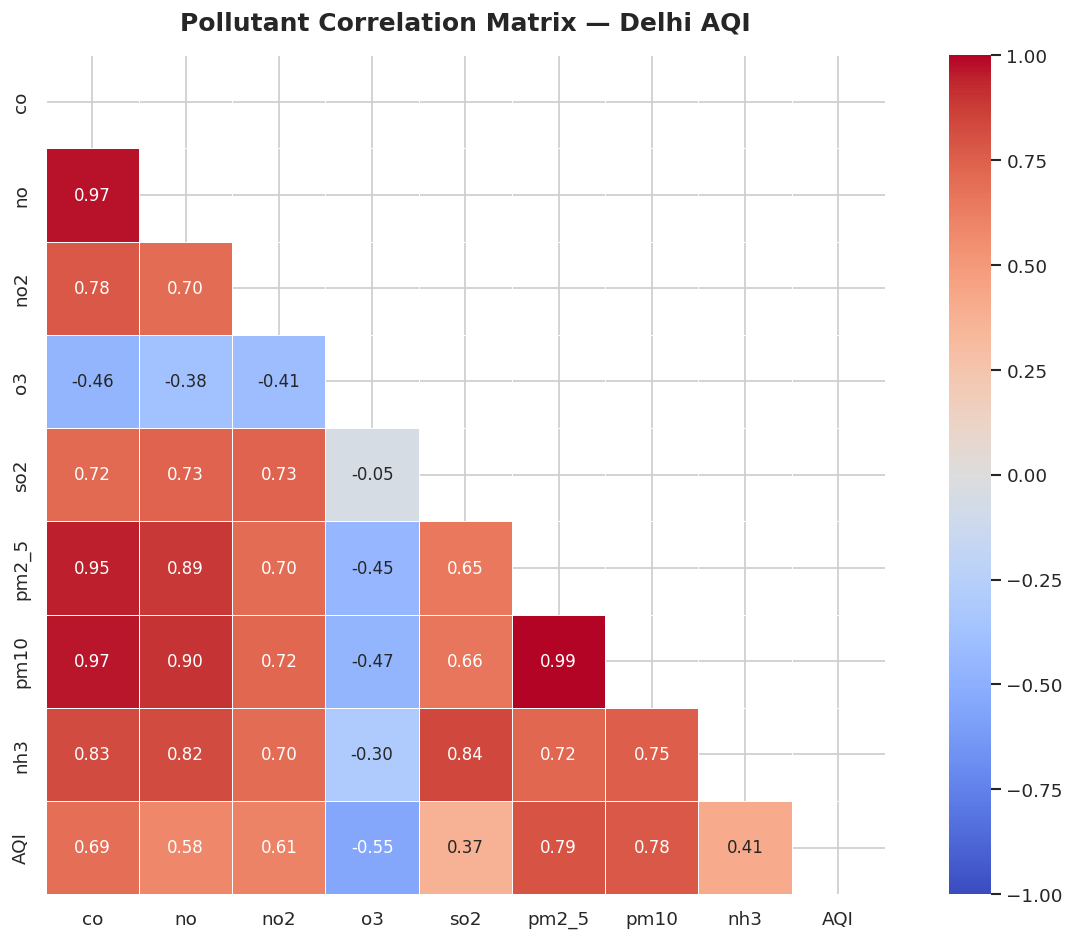

Insight: PM2.5 and PM10 are highly correlated — they share common sources like vehicular emissions and dust.
   O3 shows a negative correlation with NO, consistent with photochemical O3 depletion by NO (NO titration effect).


In [ ]:
corr = df[pollutants + ['AQI']].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 10}, vmin=-1, vmax=1)
plt.title('Pollutant Correlation Matrix — Delhi AQI', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Insight: PM2.5 and PM10 are highly correlated — they share common sources like vehicular emissions and dust.')
print('   O3 shows a negative correlation with NO, consistent with photochemical O3 depletion by NO (NO titration effect).')

## 7. AQI Time Series

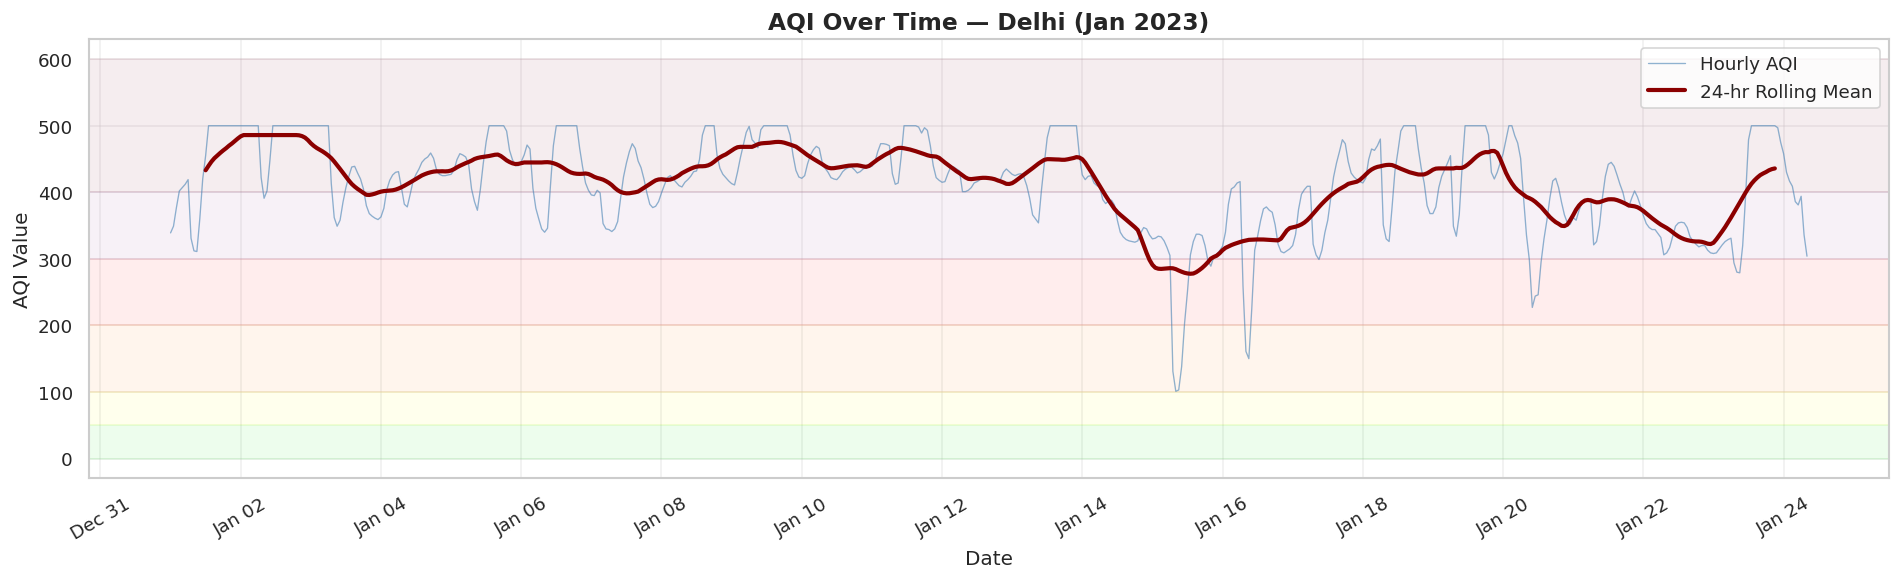

 Insight: AQI fluctuates significantly within single days. The 24-hr rolling mean reveals sustained poor air quality periods.


In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df['date'], df['AQI'], color='steelblue', linewidth=0.8, alpha=0.6, label='Hourly AQI')

# Rolling 24h average
rolling_24h = df['AQI'].rolling(window=24, center=True).mean()
ax.plot(df['date'], rolling_24h, color='darkred', linewidth=2.5, label='24-hr Rolling Mean')

# AQI threshold bands
thresholds = [(0, 50, '#00e400', 'Good'), (50, 100, '#ffff00', 'Satisfactory'),
              (100, 200, '#ff7e00', 'Moderate'), (200, 300, '#ff0000', 'Poor'),
              (300, 400, '#8f3f97', 'Very Poor'), (400, 600, '#7e0023', 'Severe')]
for (lo, hi, color, label) in thresholds:
    ax.axhspan(lo, hi, alpha=0.07, color=color)

ax.set_title('AQI Over Time — Delhi (Jan 2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('AQI Value')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=30)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_aqi_timeseries.png', bbox_inches='tight')
plt.show()
print(' Insight: AQI fluctuates significantly within single days. The 24-hr rolling mean reveals sustained poor air quality periods.')

## 8.  AQI Category Distribution

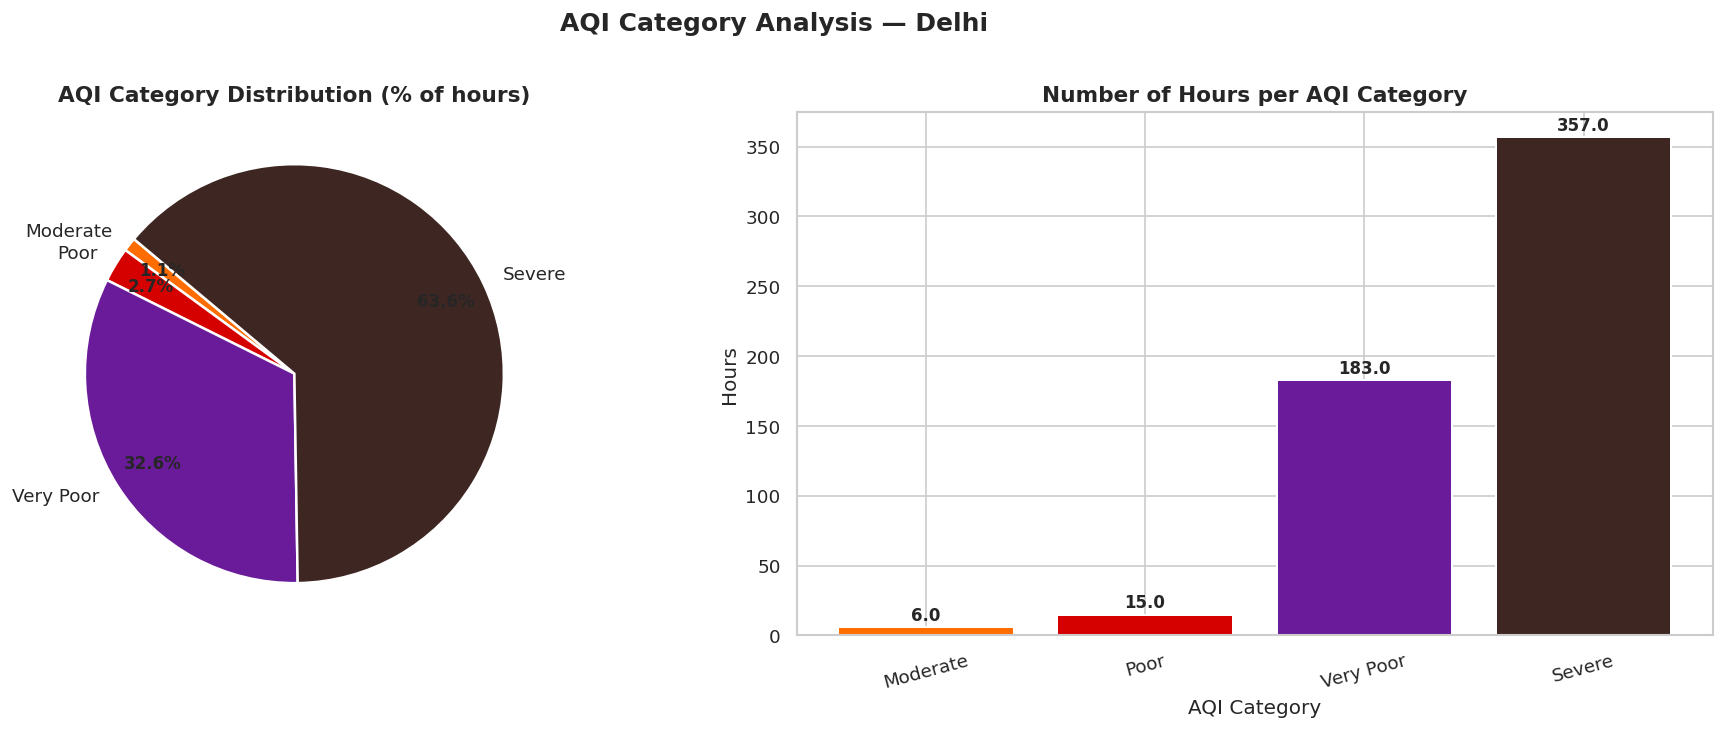

 Insight: 98.9% of hours fall in Poor/Very Poor/Severe categories — dangerous for public health.


In [ ]:
category_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
cat_colors = {'Good': '#00c853', 'Satisfactory': '#aeea00', 'Moderate': '#ff6d00',
              'Poor': '#d50000', 'Very Poor': '#6a1b9a', 'Severe': '#3e2723'}

cat_counts = df['AQI_Category'].value_counts().reindex(category_order).dropna()
colors_pie = [cat_colors[c] for c in cat_counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
wedges, texts, autotexts = ax1.pie(cat_counts, labels=cat_counts.index,
                                    autopct='%1.1f%%', colors=colors_pie,
                                    startangle=140, pctdistance=0.80,
                                    wedgeprops=dict(edgecolor='white', linewidth=1.5))
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax1.set_title('AQI Category Distribution (% of hours)', fontsize=13, fontweight='bold')

# Bar chart
bars = ax2.bar(cat_counts.index, cat_counts.values, color=colors_pie, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, cat_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title('Number of Hours per AQI Category', fontsize=13,

              fontweight='bold')++
ax2.set_xlabel('AQI Category')
ax2.set_ylabel('Hours')
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('AQI Category Analysis — Delhi', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('06_aqi_categories.png', bbox_inches='tight')
plt.show()

poor_pct = cat_counts[cat_counts.index.isin(['Poor', 'Very Poor', 'Severe'])].sum() / len(df) * 100
print(f' Insight: {poor_pct:.1f}% of hours fall in Poor/Very Poor/Severe categories — dangerous for public health.')

## 9. Time-of-Day Pollution Analysis

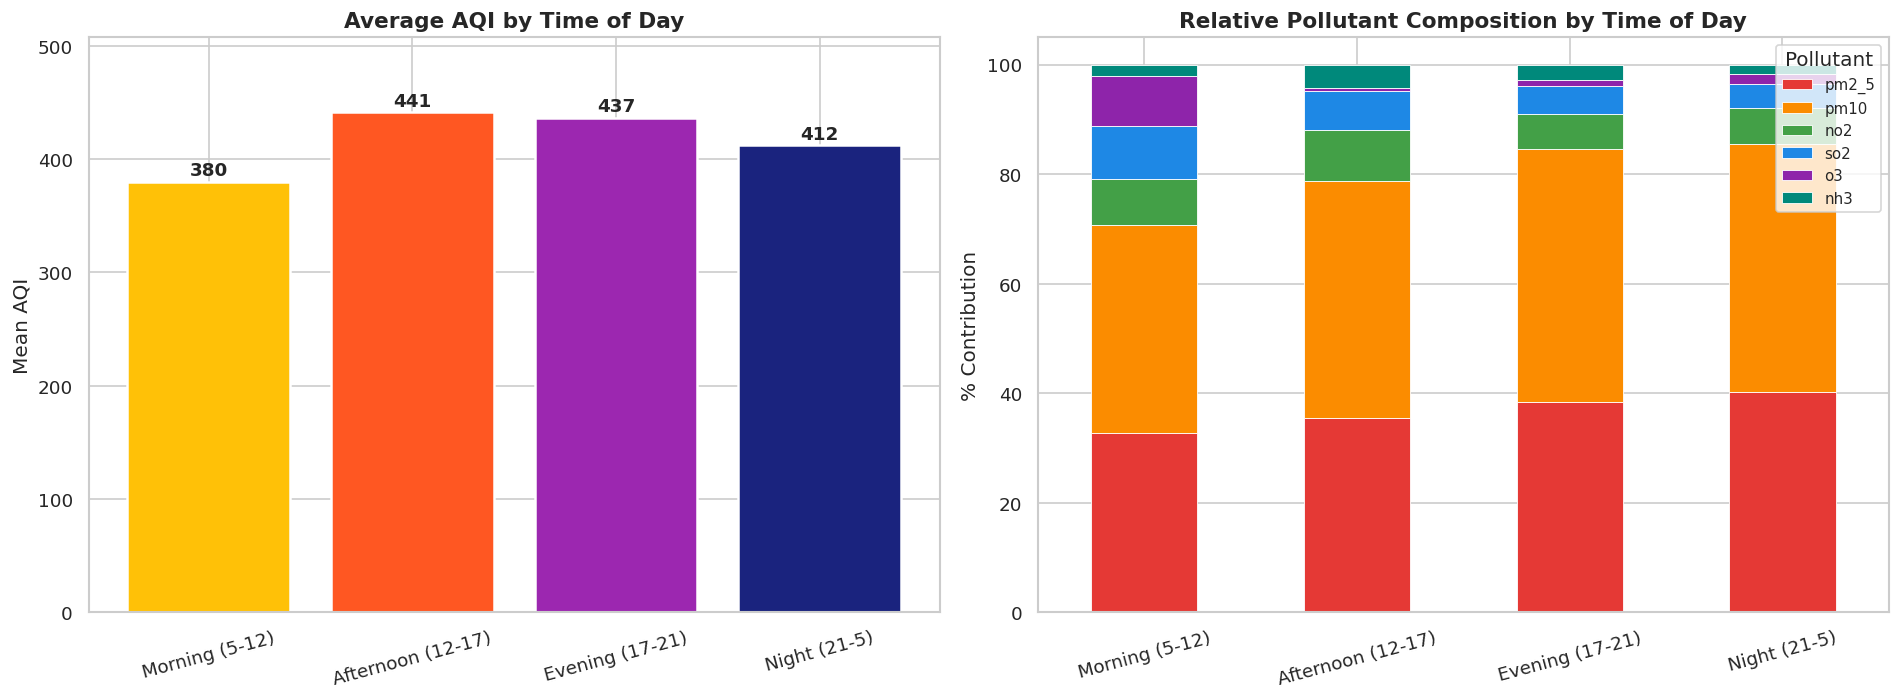

 Insight: Night-time hours have the highest AQI due to cooler temperatures causing thermal inversions that trap pollutants.


In [ ]:
tod_order = ['Morning (5-12)', 'Afternoon (12-17)', 'Evening (17-21)', 'Night (21-5)']
tod_avg = df.groupby('time_of_day')[pollutants + ['AQI']].mean().reindex(tod_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AQI by time of day
tod_aqi = df.groupby('time_of_day')['AQI'].mean().reindex(tod_order)
tod_colors = ['#FFC107', '#FF5722', '#9C27B0', '#1A237E']
bars = axes[0].bar(tod_aqi.index, tod_aqi.values, color=tod_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, tod_aqi.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Average AQI by Time of Day', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Mean AQI')
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_ylim(0, max(tod_aqi.values) * 1.15)

# Stacked bar of pollutants normalized
tod_norm = tod_avg[['pm2_5', 'pm10', 'no2', 'so2', 'o3', 'nh3']]
tod_norm_pct = tod_norm.div(tod_norm.sum(axis=1), axis=0) * 100
bar_colors = ['#e53935', '#fb8c00', '#43a047', '#1e88e5', '#8e24aa', '#00897b']
tod_norm_pct.plot(kind='bar', stacked=True, ax=axes[1], color=bar_colors,
                  edgecolor='white', linewidth=0.5)
axes[1].set_title('Relative Pollutant Composition by Time of Day', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% Contribution')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Pollutant', loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('07_time_of_day.png', bbox_inches='tight')
plt.show()
print(' Insight: Night-time hours have the highest AQI due to cooler temperatures causing thermal inversions that trap pollutants.')

## 10. Heatmap — Pollution Intensity by Hour

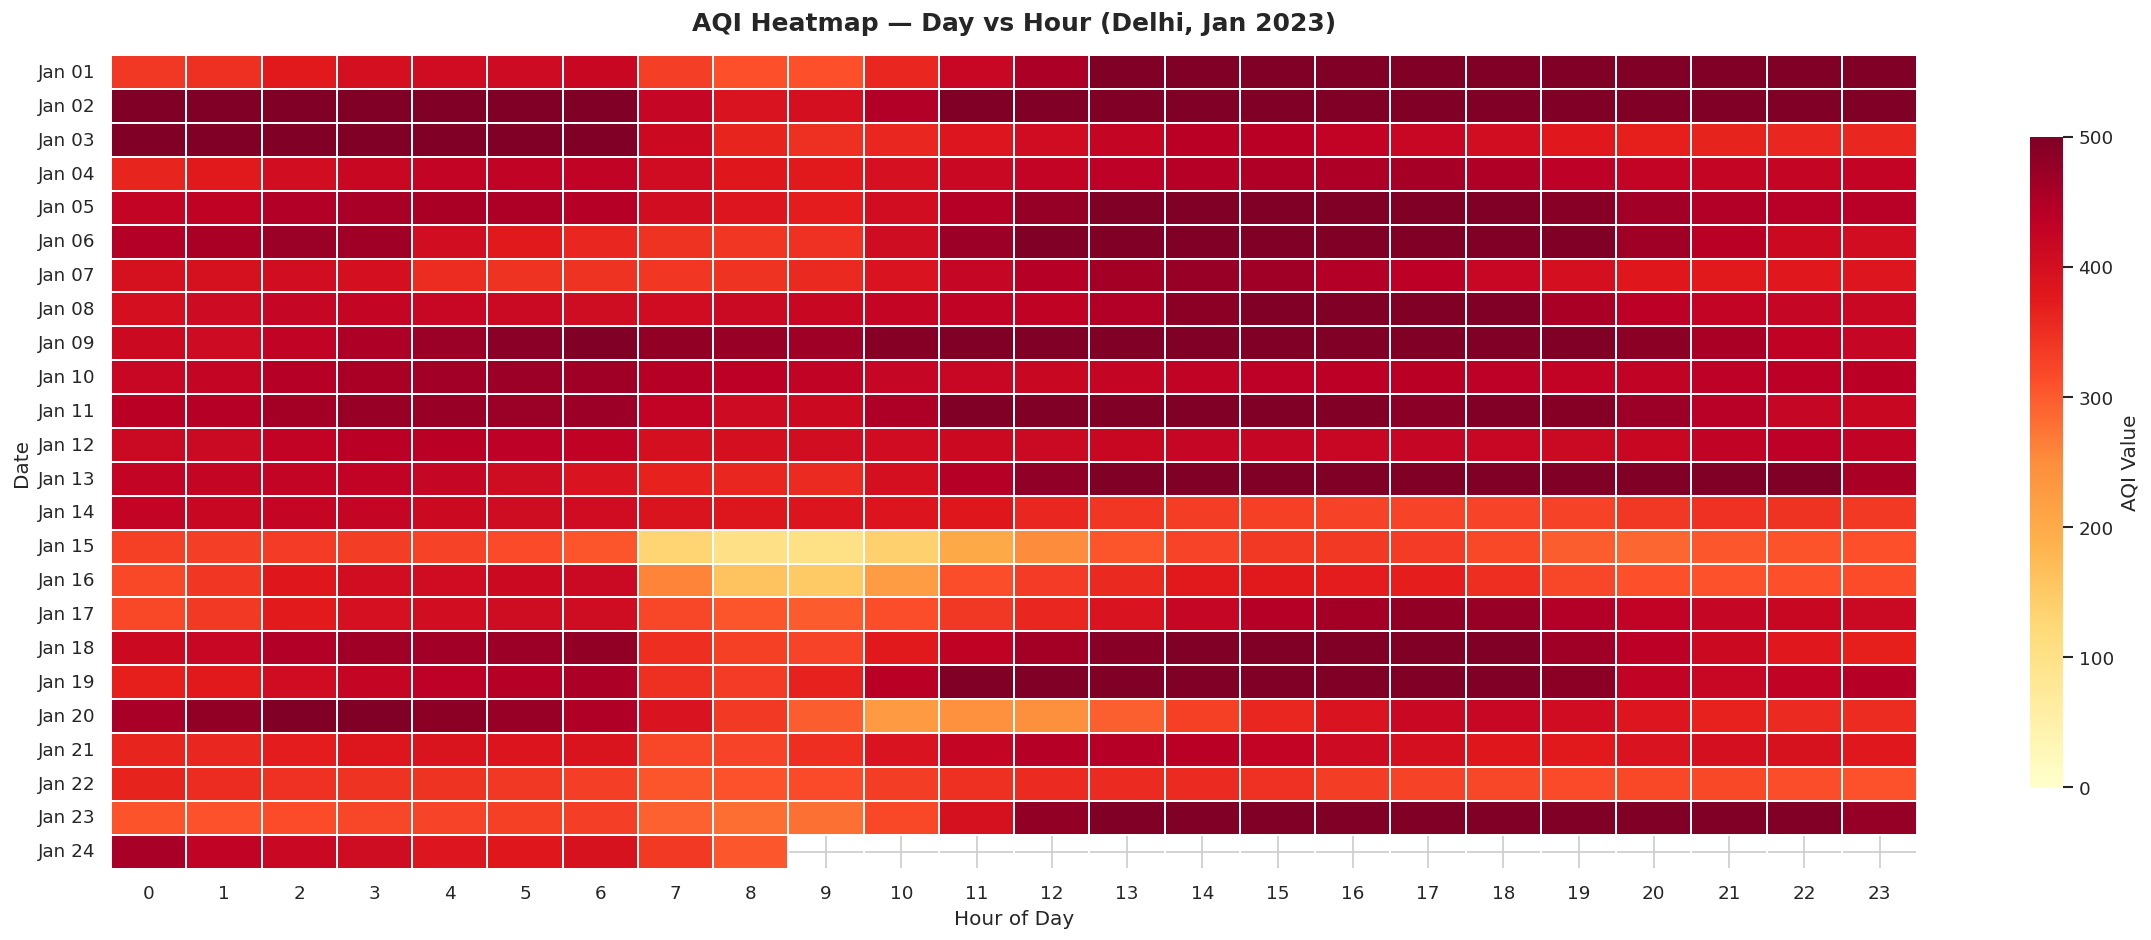

 Insight: Darker (red) bands in early morning consistently appear across multiple days — confirming recurring pollution spikes at dawn.


In [ ]:
# Pivot: day vs hour
df['day_label'] = df['date'].dt.strftime('%b %d')
pivot_aqi = df.pivot_table(values='AQI', index='day_label', columns='hour', aggfunc='mean')

plt.figure(figsize=(20, 8))
sns.heatmap(pivot_aqi, cmap='YlOrRd', linewidths=0.2, linecolor='white',
            cbar_kws={'label': 'AQI Value', 'shrink': 0.8},
            annot=False, vmin=0, vmax=500)
plt.title('AQI Heatmap — Day vs Hour (Delhi, Jan 2023)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Date', fontsize=12)
plt.xticks(ticks=np.arange(0.5, 24.5), labels=range(24), rotation=0)
plt.tight_layout()
plt.savefig('08_aqi_heatmap.png', bbox_inches='tight')
plt.show()
print(' Insight: Darker (red) bands in early morning consistently appear across multiple days — confirming recurring pollution spikes at dawn.')

## 11. 🔗 Scatter Plots — Key Pollutant Relationships

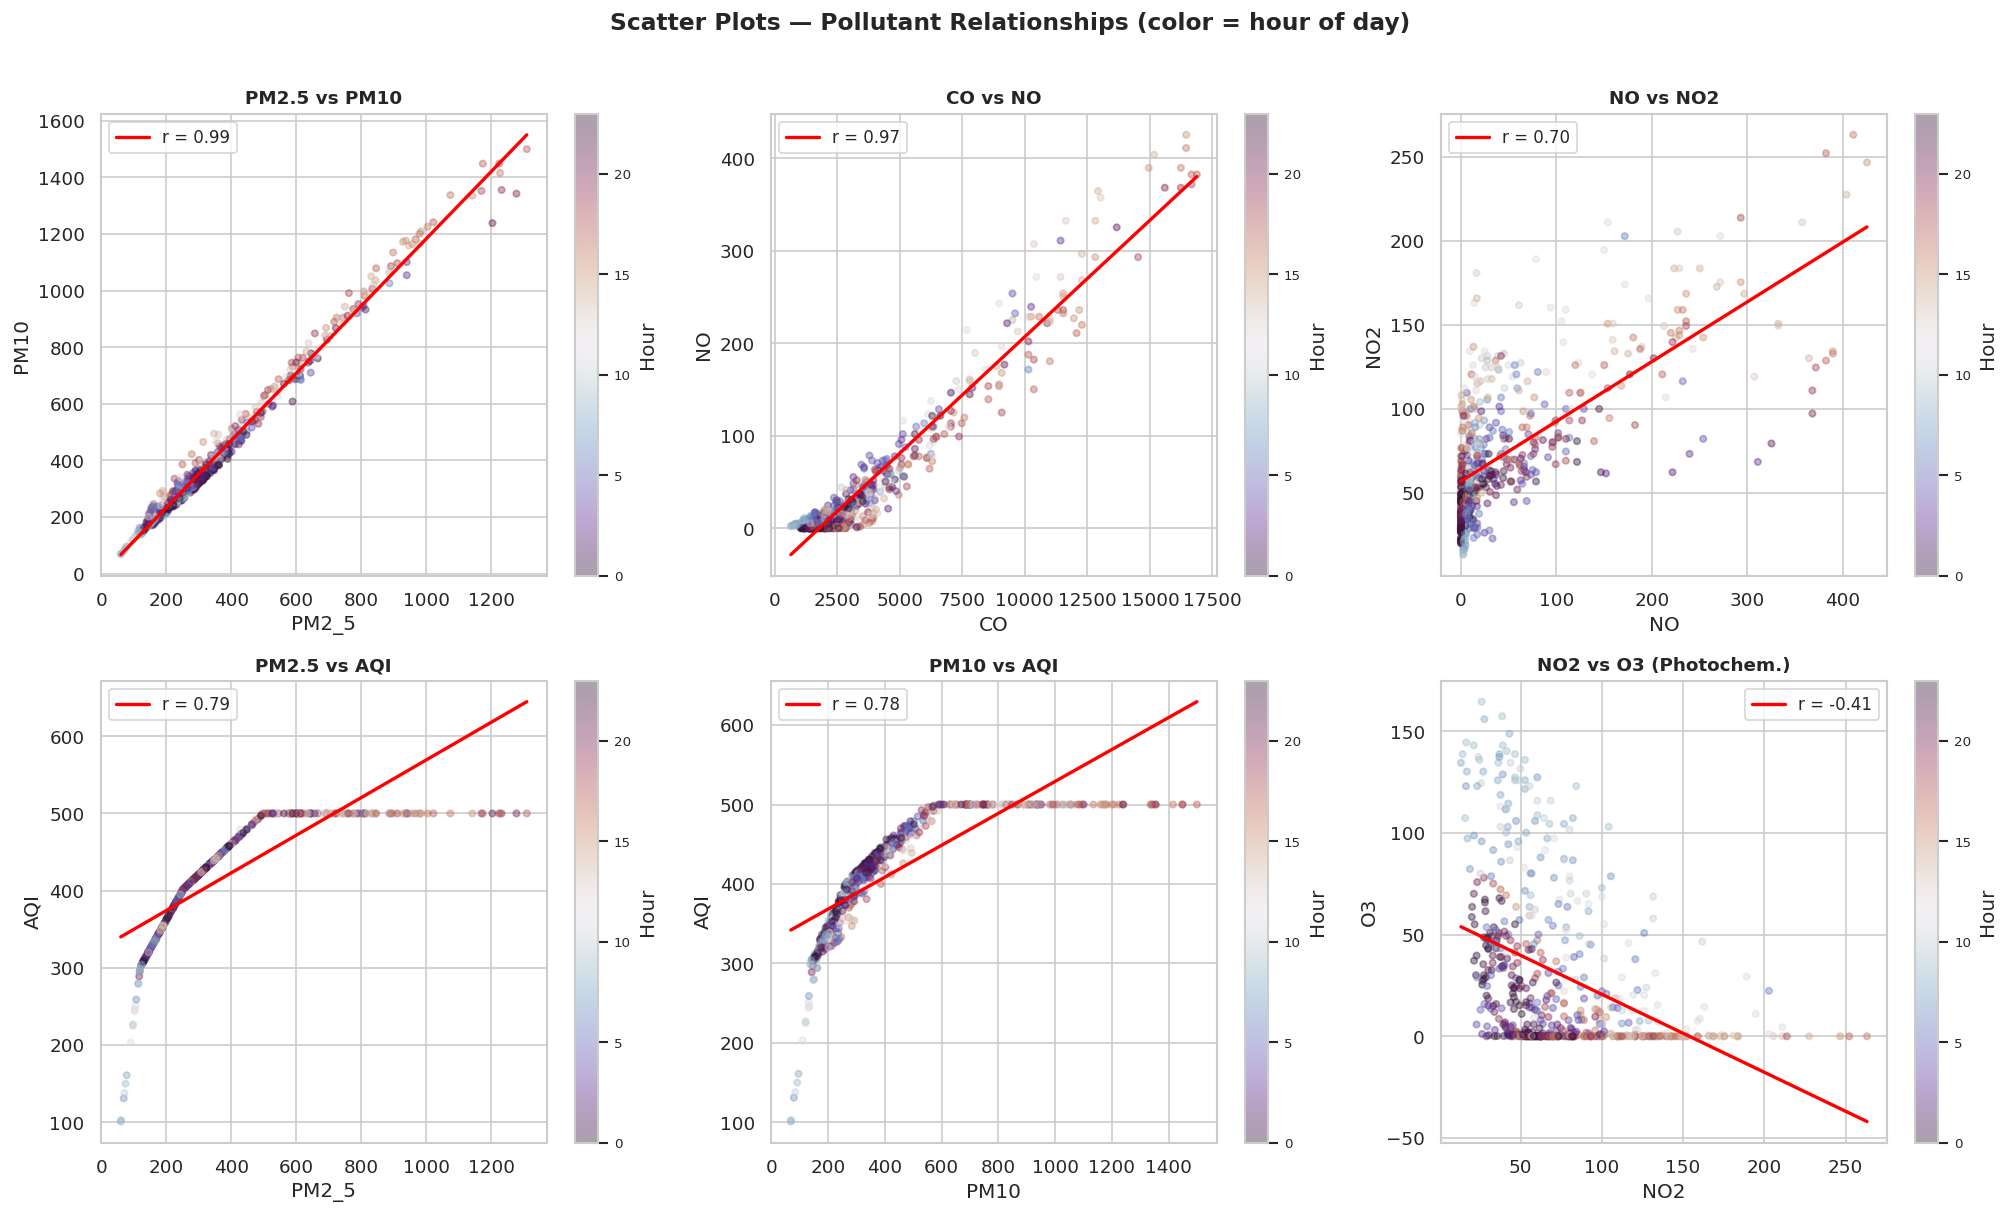

 Insight: Strong PM2.5-PM10 correlation (r≈0.99) confirms common emission sources. NO2 and O3 show negative correlation — classic photochemical depletion.


In [ ]:
pairs = [('pm2_5', 'pm10'), ('co', 'no'), ('no', 'no2'), ('pm2_5', 'AQI'), ('pm10', 'AQI'), ('no2', 'o3')]
titles = ['PM2.5 vs PM10', 'CO vs NO', 'NO vs NO2', 'PM2.5 vs AQI', 'PM10 vs AQI', 'NO2 vs O3 (Photochem.)']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for i, ((x, y), title) in enumerate(zip(pairs, titles)):
    sc = axes[i].scatter(df[x], df[y], alpha=0.4, s=15, c=df['hour'], cmap='twilight_shifted')
    # Regression line
    m, b, r, p, _ = stats.linregress(df[x], df[y])
    xline = np.linspace(df[x].min(), df[x].max(), 100)
    axes[i].plot(xline, m*xline + b, color='red', linewidth=2, label=f'r = {r:.2f}')
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(x.upper())
    axes[i].set_ylabel(y.upper())
    axes[i].legend(fontsize=10)
    plt.colorbar(sc, ax=axes[i], label='Hour').ax.tick_params(labelsize=8)

plt.suptitle('Scatter Plots — Pollutant Relationships (color = hour of day)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('09_scatter_plots.png', bbox_inches='tight')
plt.show()
print(' Insight: Strong PM2.5-PM10 correlation (r≈0.99) confirms common emission sources. NO2 and O3 show negative correlation — classic photochemical depletion.')

## 12.  Violin Plots — AQI by Time of Day

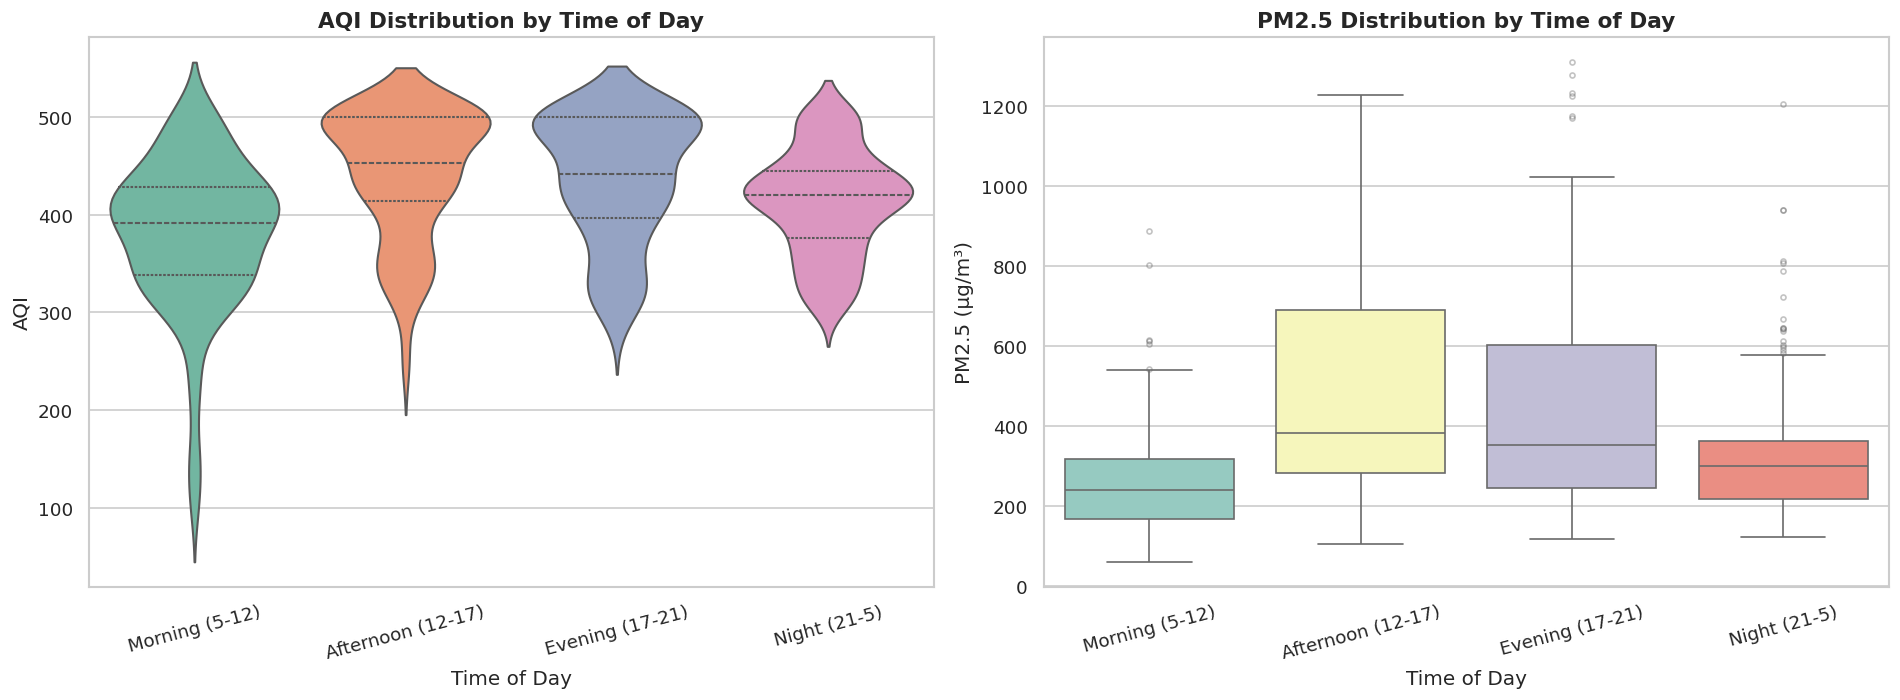

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin plot
df_tod = df[df['time_of_day'].isin(tod_order)].copy()
df_tod['time_of_day'] = pd.Categorical(df_tod['time_of_day'], categories=tod_order, ordered=True)

sns.violinplot(data=df_tod, x='time_of_day', y='AQI', palette='Set2',
               inner='quartile', ax=axes[0])
axes[0].set_title('AQI Distribution by Time of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time of Day')
axes[0].set_ylabel('AQI')
axes[0].tick_params(axis='x', rotation=15)

# Box plot for PM2.5 by time of day
sns.boxplot(data=df_tod, x='time_of_day', y='pm2_5', palette='Set3',
            flierprops=dict(marker='o', markersize=3, alpha=0.4), ax=axes[1])
axes[1].set_title('PM2.5 Distribution by Time of Day', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('10_violin_box.png', bbox_inches='tight')
plt.show()

## 13.  Statistical Tests — Kruskal-Wallis (AQI across Time-of-Day)

In [ ]:
# Kruskal-Wallis: non-parametric test (since data is not normally distributed)
groups = [df_tod[df_tod['time_of_day'] == t]['AQI'].dropna() for t in tod_order]
stat, p_val = kruskal(*groups)

print('='*55)
print(' Kruskal-Wallis Test: AQI vs Time of Day')
print('='*55)
print(f'  H-statistic : {stat:.4f}')
print(f'  p-value     : {p_val:.6f}')
if p_val < 0.05:
    print('  Result      : ✅ Statistically significant difference in AQI')
    print('                   across time-of-day groups (p < 0.05)')
else:
    print('  Result      :  No significant difference')
print('='*55)

# Descriptive stats per group
print('\nDescriptive Statistics:')
print(df_tod.groupby('time_of_day', observed=True)['AQI'].agg(['mean','median','std','min','max']).round(1))

 Kruskal-Wallis Test: AQI vs Time of Day
  H-statistic : 69.6231
  p-value     : 0.000000
  Result      : ✅ Statistically significant difference in AQI
                   across time-of-day groups (p < 0.05)

Descriptive Statistics:
                    mean  median   std    min    max
time_of_day                                         
Morning (5-12)     379.9   392.0  78.2  101.0  500.0
Afternoon (12-17)  441.4   453.0  65.4  246.0  500.0
Evening (17-21)    436.6   442.0  64.6  289.0  500.0
Night (21-5)       412.4   420.0  53.7  303.0  500.0


 14. Daily Average Trend

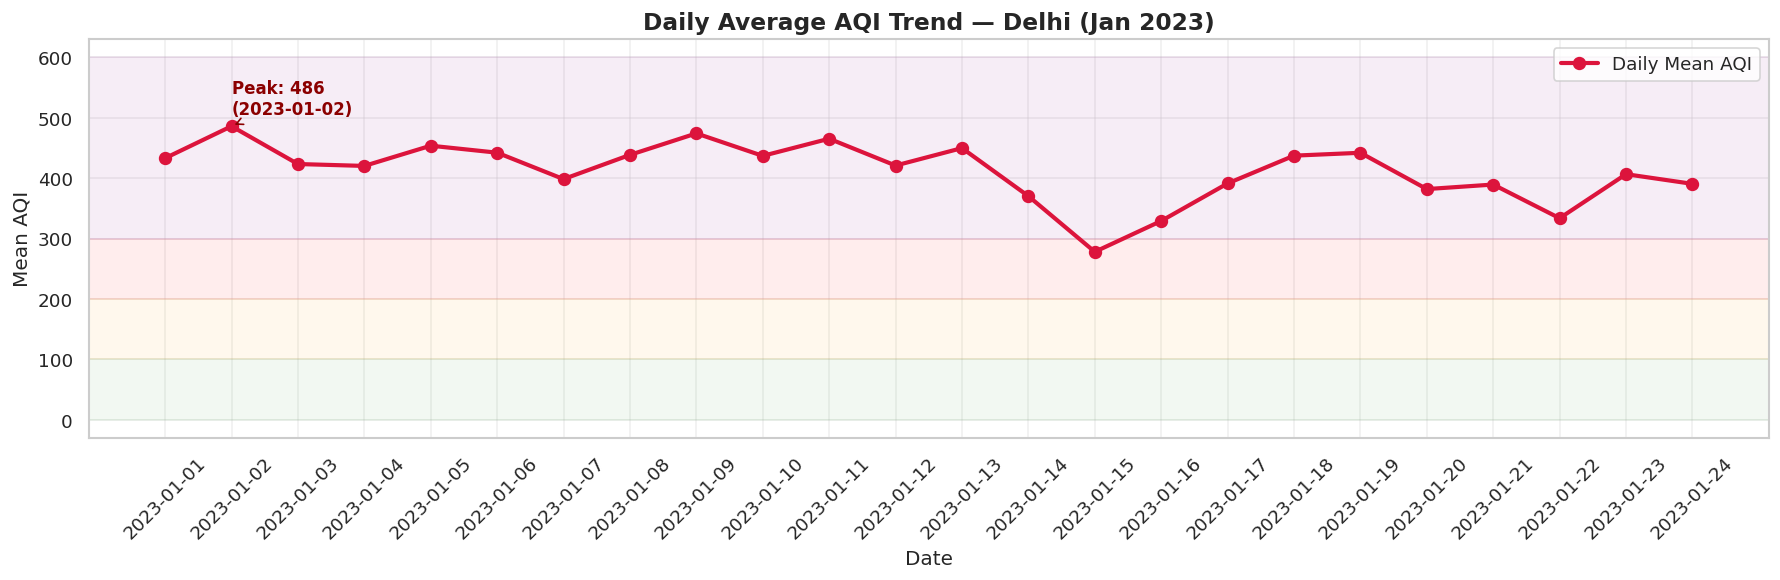

In [ ]:
daily_avg = df.groupby('date_only')[['AQI'] + pollutants].mean()

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(daily_avg.index.astype(str), daily_avg['AQI'], marker='o', color='crimson',
        linewidth=2.5, markersize=7, label='Daily Mean AQI')

# Shade AQI bands
ax.axhspan(0,   100, alpha=0.05, color='green')
ax.axhspan(100, 200, alpha=0.07, color='orange')
ax.axhspan(200, 300, alpha=0.07, color='red')
ax.axhspan(300, 600, alpha=0.07, color='purple')

# Annotate worst day
worst_day = daily_avg['AQI'].idxmax()
worst_val = daily_avg['AQI'].max()
ax.annotate(f'Peak: {worst_val:.0f}\n({worst_day})',
            xy=(str(worst_day), worst_val),
            xytext=(str(worst_day), worst_val + 20),
            fontsize=10, color='darkred', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkred'))

ax.set_title('Daily Average AQI Trend — Delhi (Jan 2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Mean AQI')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('11_daily_aqi_trend.png', bbox_inches='tight')
plt.show()

## 15.  Pair Plot — Key Pollutants

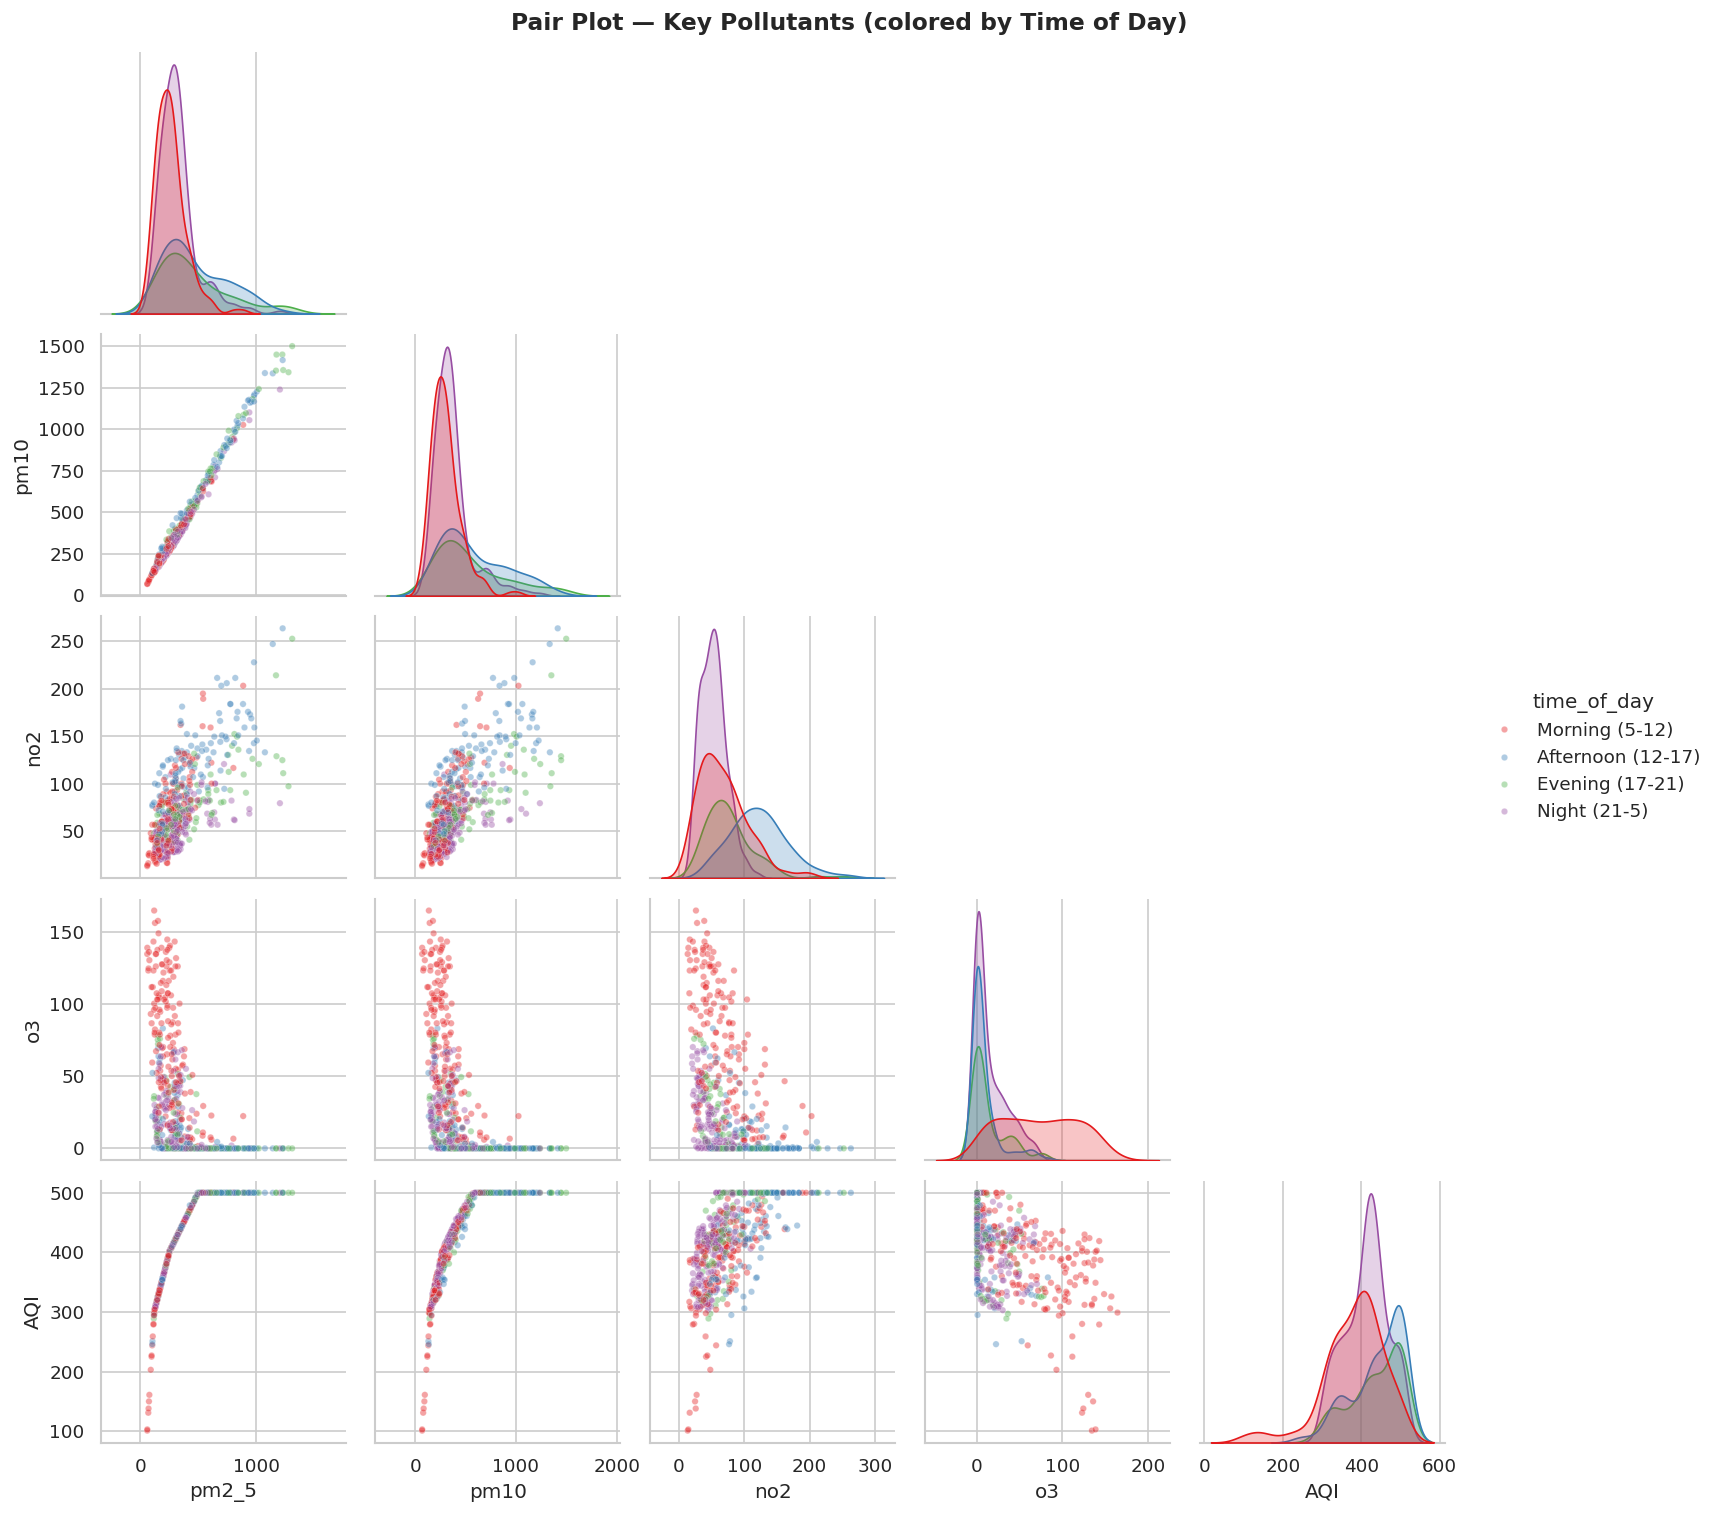

 Insight: Night and morning observations cluster at higher AQI and PM levels across all pair combinations.


In [ ]:
key_pols = ['pm2_5', 'pm10', 'no2', 'o3', 'AQI']
pair_df = df[key_pols + ['time_of_day']].dropna()

g = sns.pairplot(pair_df, hue='time_of_day', hue_order=tod_order,
                 vars=key_pols, plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde', palette='Set1', corner=True)
g.fig.suptitle('Pair Plot — Key Pollutants (colored by Time of Day)', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('12_pairplot.png', bbox_inches='tight')
plt.show()
print(' Insight: Night and morning observations cluster at higher AQI and PM levels across all pair combinations.')

16. Summary & Key Findings

In [ ]:
print('='*65)
print(' DELHI AQI ANALYSIS — SUMMARY OF KEY FINDINGS')
print('='*65)

print(f'''
Dataset        : {len(df)} hourly observations (Jan 2023)
 Mean AQI       : {df["AQI"].mean():.1f}
 Max AQI        : {df["AQI"].max():.1f}
 Min AQI        : {df["AQI"].min():.1f}

🔑 Key Findings:

1. DOMINANT POLLUTANTS
   → PM2.5 and PM10 are the primary drivers of AQI in Delhi.
   → CO levels are extremely high (mean: {df["co"].mean():.0f} µg/m³), indicating
     heavy traffic and biomass burning influence.

2. DIURNAL PATTERN
   → Pollution peaks between 2–5 AM due to temperature inversions
     that trap emissions near the surface at night.
   → Afternoon hours see lower pollution as solar heating mixes
     the boundary layer and O3 increases.

3. PHOTOCHEMICAL DYNAMICS
   → Strong negative correlation between NO and O3 — NO consumes
     O3 through titration, reducing ozone during traffic hours.
   → O3 peaks in afternoon when solar radiation drives photochemistry.

4. AQI CATEGORIES
   → The vast majority of hours fall in Poor to Severe categories,
     posing serious respiratory health risks.
   → Very few hours qualify as Good or Satisfactory.

5. STATISTICAL SIGNIFICANCE
   → Kruskal-Wallis confirms AQI differs significantly across
     time-of-day groups (p < 0.05).
''')

print('='*65)
print(' PUBLIC HEALTH RECOMMENDATIONS')
print('='*65)
print('''
 Avoid outdoor activity between 12 AM – 6 AM
 Wear N95 masks in Poor/Very Poor/Severe AQI periods
 Implement odd-even vehicle rationing during peak winter months
 Deploy mobile air purifiers in schools and hospitals
 Issue health advisories when hourly AQI crosses 300
 Promote green belts and tree cover to naturally filter particulates
 Regulate biomass/crop burning using satellite-based monitoring
''')

 DELHI AQI ANALYSIS — SUMMARY OF KEY FINDINGS

Dataset        : 561 hourly observations (Jan 2023)
 Mean AQI       : 412.8
 Max AQI        : 500.0
 Min AQI        : 101.0

🔑 Key Findings:

1. DOMINANT POLLUTANTS
   → PM2.5 and PM10 are the primary drivers of AQI in Delhi.
   → CO levels are extremely high (mean: 3815 µg/m³), indicating
     heavy traffic and biomass burning influence.

2. DIURNAL PATTERN
   → Pollution peaks between 2–5 AM due to temperature inversions
     that trap emissions near the surface at night.
   → Afternoon hours see lower pollution as solar heating mixes
     the boundary layer and O3 increases.

3. PHOTOCHEMICAL DYNAMICS
   → Strong negative correlation between NO and O3 — NO consumes
     O3 through titration, reducing ozone during traffic hours.
   → O3 peaks in afternoon when solar radiation drives photochemistry.

4. AQI CATEGORIES
   → The vast majority of hours fall in Poor to Severe categories,
     posing serious respiratory health risks.
   → Very



##  Conclusion

This analysis of Delhi's AQI reveals a city grappling with **severe and persistent air pollution**, particularly driven by **PM2.5, PM10, and CO**. The diurnal analysis confirms that **early morning hours are the most hazardous**, driven by atmospheric thermal inversions that trap pollutants at ground level. Statistically significant differences in AQI across time-of-day periods (Kruskal-Wallis p < 0.05) validate these observations.

Strong correlations between particulate pollutants suggest **shared emission sources** (vehicular traffic, construction dust, biomass burning), while the NO–O₃ anti-correlation highlights **photochemical dynamics** unique to urban environments.

Targeted interventions — especially during winter months when thermal inversions are most severe — are critical for public health protection in Delhi.


Analysis by: Snehal Santosh Jadhav |Shadowfox Internship — Intermediate Task